In [5]:
import numpy as np
import random
import os
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.decomposition import PCA
from tqdm import tqdm
import re

In [ ]:
SEED = 0
FEATURES_PATH = 'features_pairs.npy'
FEATURES_METADATA_PATH = 'metadata_pairs.pkl'
PATHS = [
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-02-22_Exp1_Ctx-Gef-Sor",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-02-24_Exp2_Tra-Shc-Pic",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-02-26_Exp3_Azd53-Bez-Azd85",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-03-08_Exp1_Ctx-Gef-Sor",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-03-10_Exp2_Tra-Shc-Pic",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-03-23_Exp3_Azd53-Bez-Azd85",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-04-12_Exp1_Ctx-Gef-Sor",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-04-26_Exp2_Tra-Shc-Pic",
    "/mnt/imaging.data/pgagliardi/MCF10A_TimeLapse_Geminin-Drugs/2019-05-03_Exp3_Azd53-Bez-Azd85"
]


def set_seed(seed):
    # Python
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # NumPy
    np.random.seed(seed)


def compute_bootstrap_ci(data, num_bootstrap_samples=1000, ci=95):
    n = len(data)
    bootstrap_means = []

    for _ in range(num_bootstrap_samples):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_means.append(np.mean(sample))

    lower_bound = np.percentile(bootstrap_means, (100 - ci) / 2)
    upper_bound = np.percentile(bootstrap_means, 100 - (100 - ci) / 2)

    return lower_bound, upper_bound


def probe(features, labels, label_name, time_horizon, batch_labels):
    X = features
    y = np.asarray(labels)

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    # Use LeaveOneGroupOut for cross-validation
    cv = LeaveOneGroupOut()

    # Collect coefficients across folds
    importances = {}
    acc_scores = []

    for train_idx, test_idx in cv.split(X, y, groups=batch_labels):
        if len(np.unique(y[train_idx])) < 2 or len(np.unique(y[test_idx])) < 2:
            # Skip this fold if it doesn't have both classes in train or test
            continue
        model = clone(clf)
        model.fit(X[train_idx], y[train_idx])

        # Extract coefficients from the logistic regression step
        coef = model.named_steps["logisticregression"].coef_[0]

        # Evaluate accuracy on the test set
        acc = model.score(X[test_idx], y[test_idx])
        acc_scores.append(acc)

        for c in range(len(coef)):
            if c not in importances:
                importances[c] = []
            importances[c].append(np.float64(abs(coef[c])))

    acc_mean = np.mean(acc_scores)
    acc_lo, acc_hi = compute_bootstrap_ci(acc_scores)

    res = {
        "label_name": label_name,
        "time_horizon": time_horizon,
        "acc": acc_mean,
        "acc_lo": acc_lo,
        "acc_hi": acc_hi,
        "imps": [],
        "imps_lo": [],
        "imps_hi": [],
    }

    for c in importances:
        importance_values = importances[c]
        importance_mean = np.mean(importance_values)
        importance_lo, importance_hi = compute_bootstrap_ci(importance_values)

        res["imps"].append(importance_mean)
        res["imps_lo"].append(importance_lo)
        res["imps_hi"].append(importance_hi)

    return res


def main():
    features = np.load(FEATURES_PATH)
    with open(FEATURES_METADATA_PATH, 'rb') as f:
        metadata = pickle.load(f)

    exp_masks = np.array([m['Path'] in PATHS for m in metadata])
    features = features[exp_masks]
    metadata = [m for m, mask in zip(metadata, exp_masks) if mask]

    mutations = [m['Cell_type'] for m in metadata]
    mutations = [re.search(r"MCF10A_(.*?)_Clone", n).group(1) for n in mutations]
    mutations = np.array(mutations)
    treatments = np.array([m['Inhibitor'] for m in metadata])
    batch_labels = np.array([m['Path'] for m in metadata])

    t1s = [m['t1'] for m in metadata]
    t2s = [m['t2'] for m in metadata]

    order_labels = np.array([0 if t1 < t2 else 1 for t1, t2 in zip(t1s, t2s, strict=True)])

    results = []
    for time_horizon in [16]:
        pref_pool_feat = features[:, 0, :time_horizon, :].mean(axis=1)
        pref_pool_feat_same_loc_t2 = features[:, 1, :time_horizon, :].mean(axis=1)
        pref_pool_feat_diff_loc_t2 = features[:, 2, :time_horizon, :].mean(axis=1)

        pca = make_pipeline(
            StandardScaler(),
            PCA(n_components=16)
        )
        pca.fit(pref_pool_feat)
        pref_pool_feat = pca.transform(pref_pool_feat)
        pref_pool_feat_same_loc_t2 = pca.transform(pref_pool_feat_same_loc_t2)
        pref_pool_feat_diff_loc_t2 = pca.transform(pref_pool_feat_diff_loc_t2)

        order_features_same_loc_t2 = pref_pool_feat_same_loc_t2 - pref_pool_feat
        order_features_diff_loc_t2 = pref_pool_feat_diff_loc_t2 - pref_pool_feat

        for mutation in np.unique(mutations):
            for treatment in tqdm(np.unique(treatments)):
                if treatment == "DMSO":
                    continue
                treatment_mask = treatments == treatment
                mutation_mask = mutations == mutation
                dmso_mask = treatments == "DMSO"
                treated_feat = pref_pool_feat[treatment_mask & mutation_mask]
                dmso_feat = pref_pool_feat[dmso_mask & mutation_mask]
                if len(treated_feat) == 0 or len(dmso_feat) == 0:
                    continue
                labels = np.concatenate([np.zeros(len(dmso_feat)), np.ones(len(treated_feat))])
                features_combined = np.concatenate([dmso_feat, treated_feat], axis=0)
                b_labels = np.concatenate([batch_labels[dmso_mask & mutation_mask], batch_labels[treatment_mask & mutation_mask]], axis=0)
                results.append(probe(features_combined, labels, f"{mutation} - {treatment} vs DMSO", time_horizon, b_labels))

        results.append(probe(order_features_same_loc_t2, order_labels, "order same loc", time_horizon, batch_labels))
        results.append(probe(order_features_diff_loc_t2, order_labels, "order diff loc", time_horizon, batch_labels))

    return results

res = main()

  0%|          | 0/10 [00:00<?, ?it/s]


TypeError: LeaveOneGroupOut.split() got an unexpected keyword argument 'shuffle'

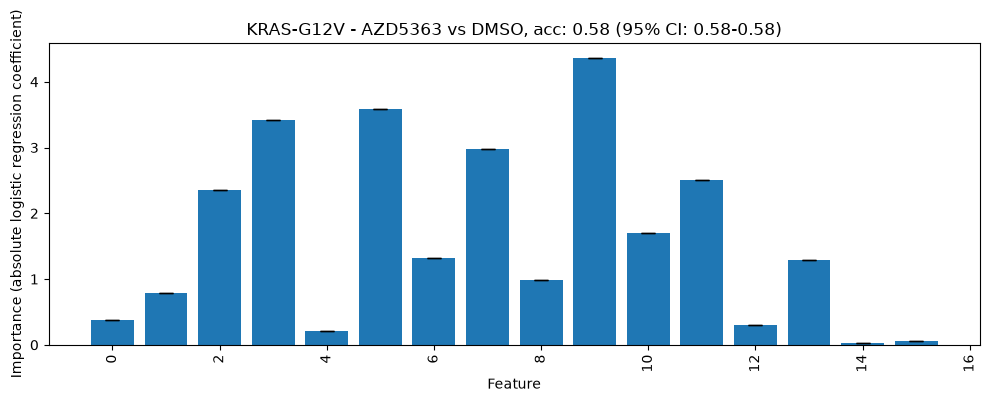

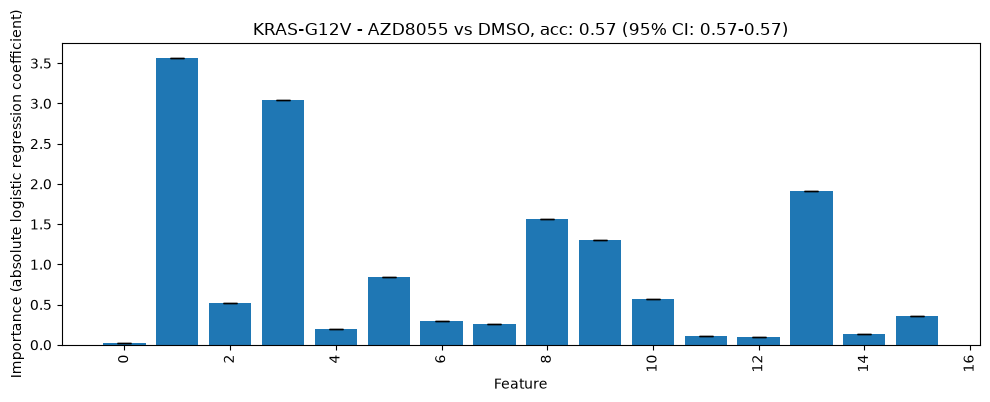

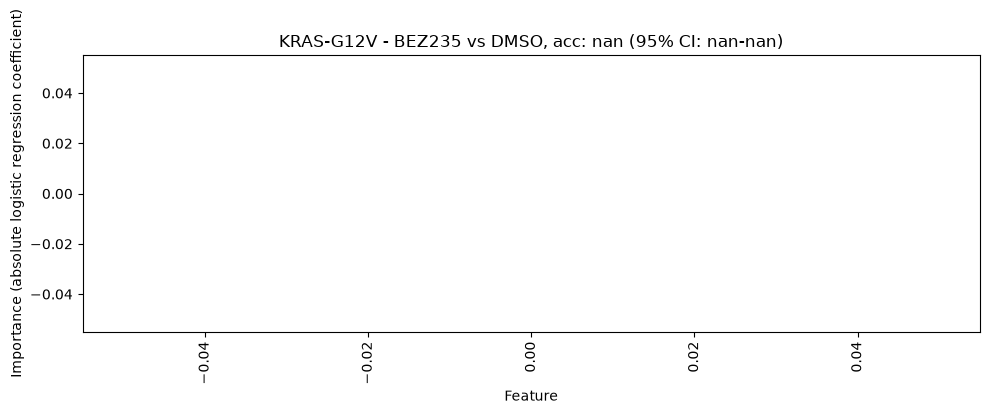

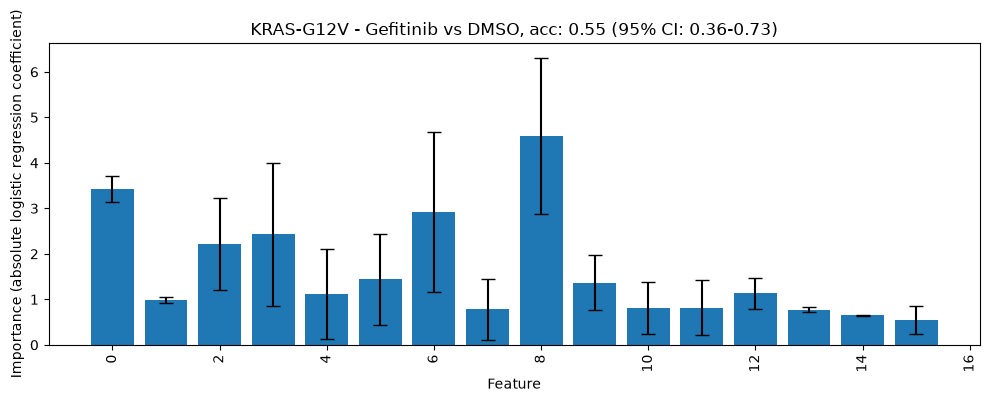

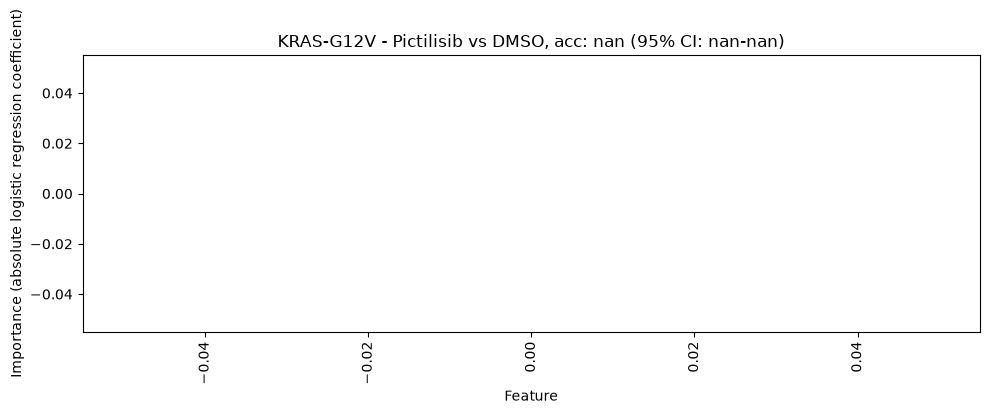

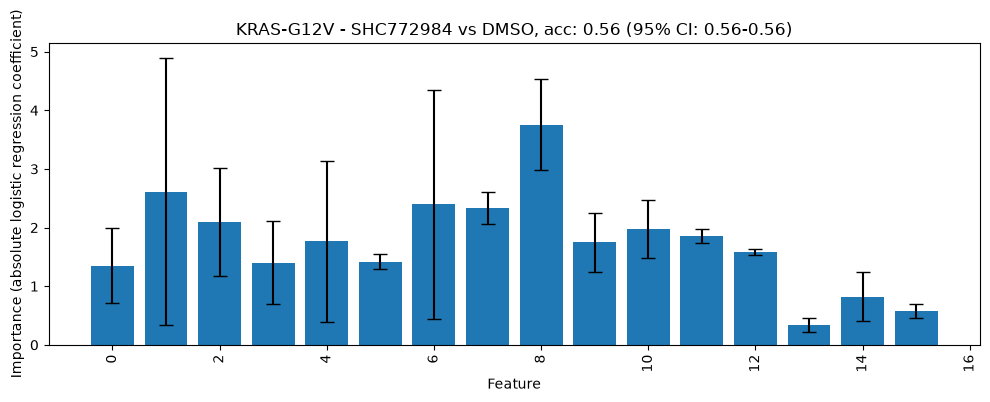

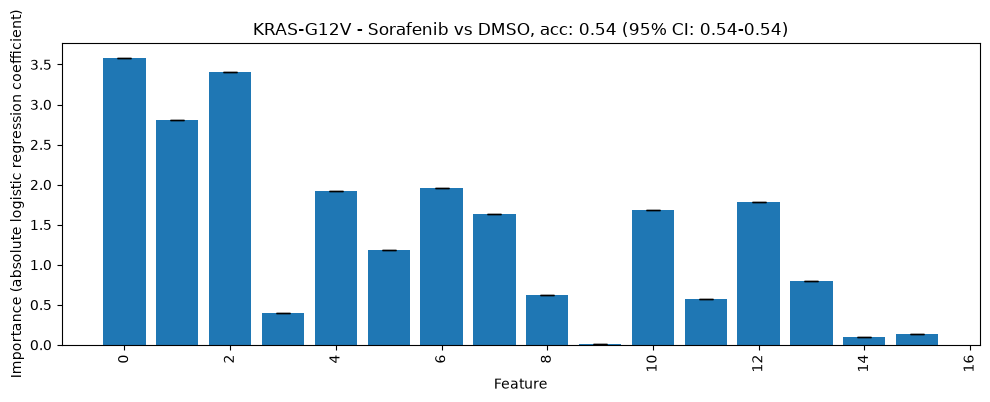

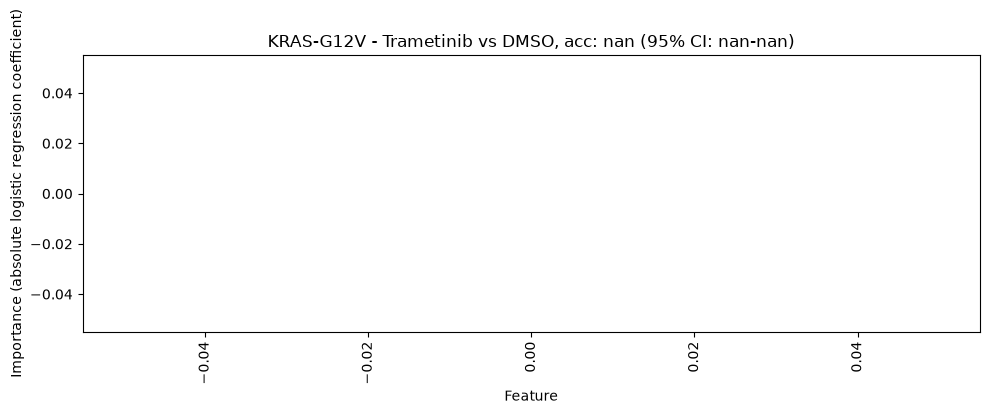

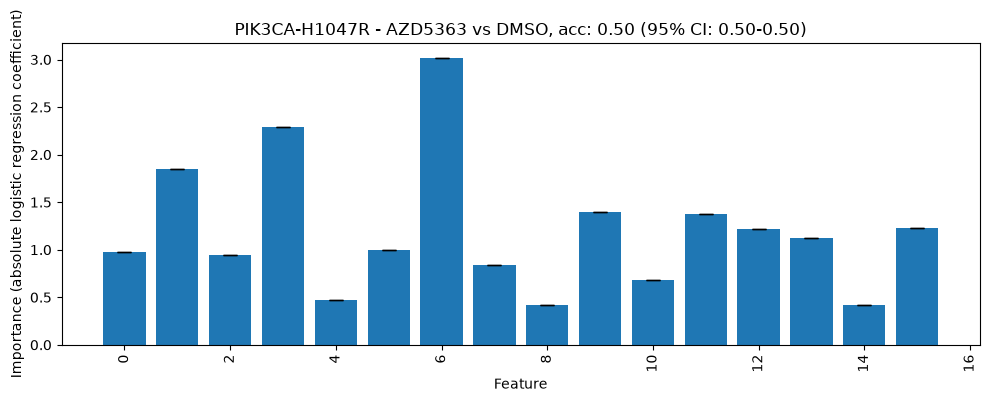

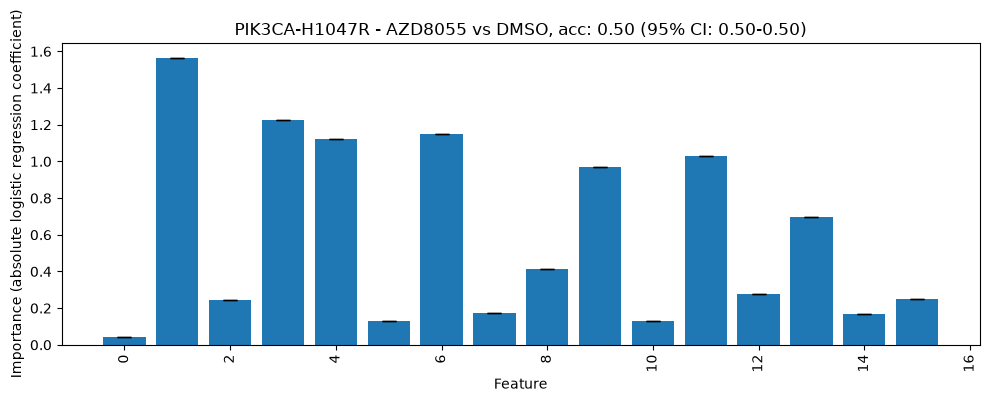

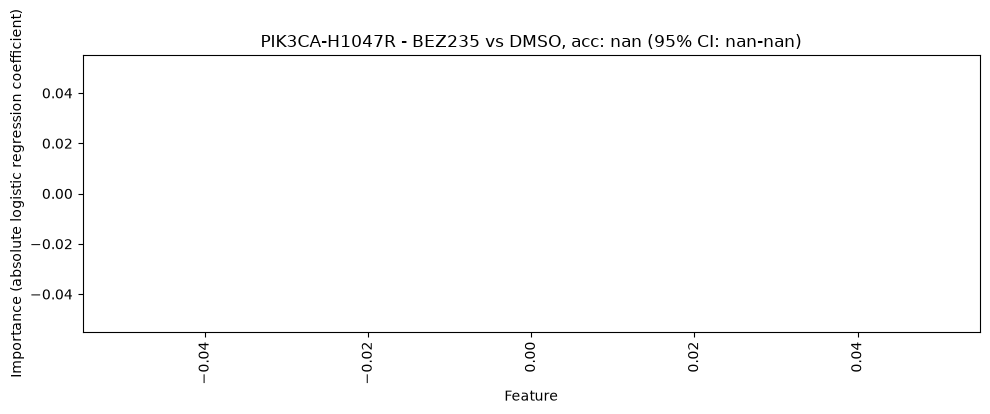

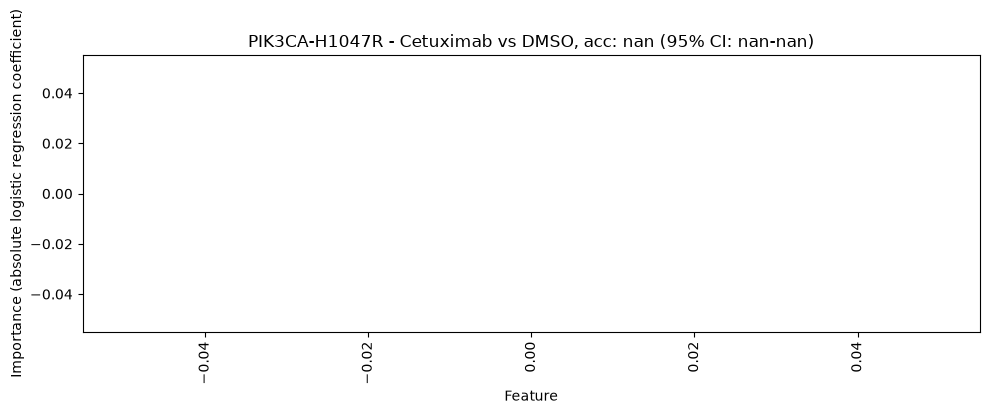

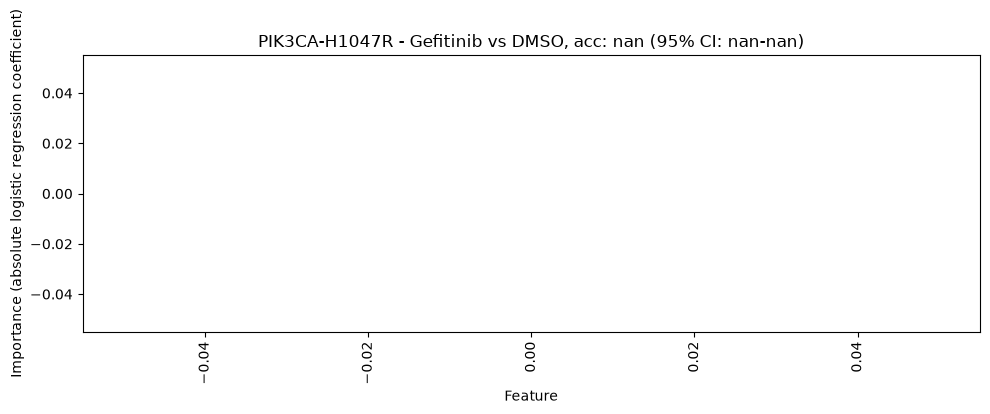

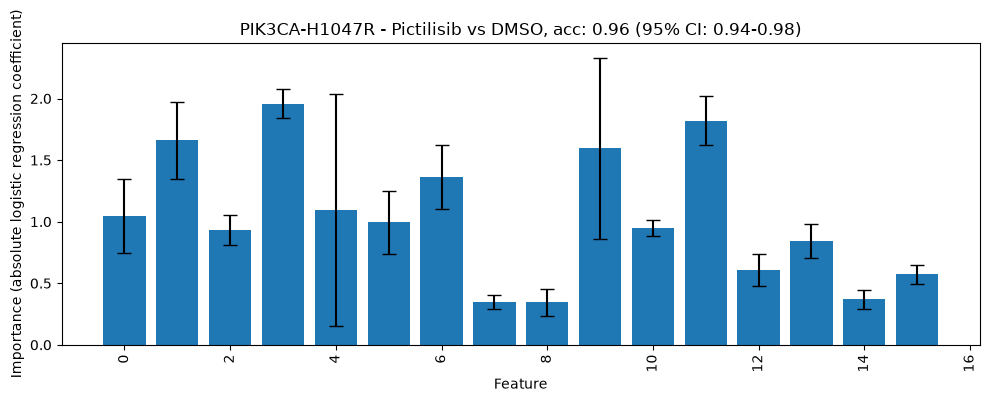

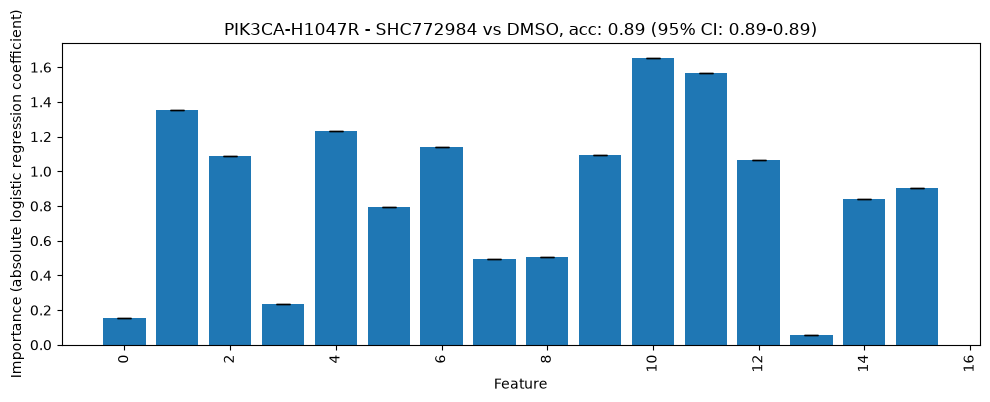

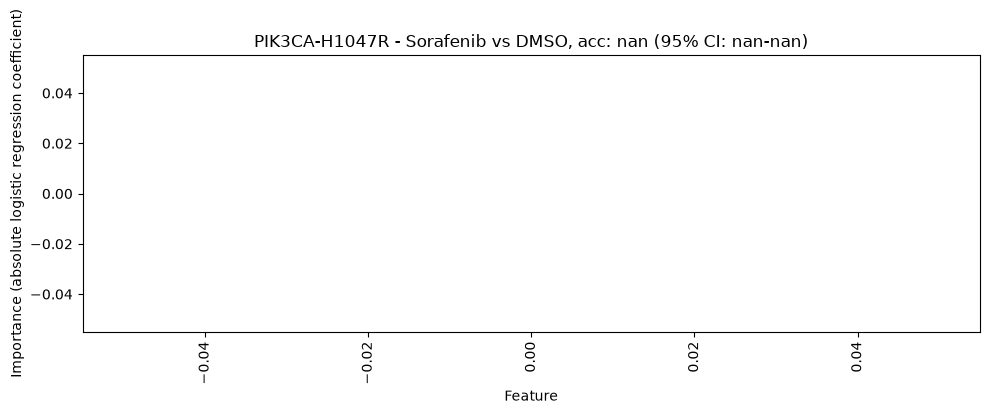

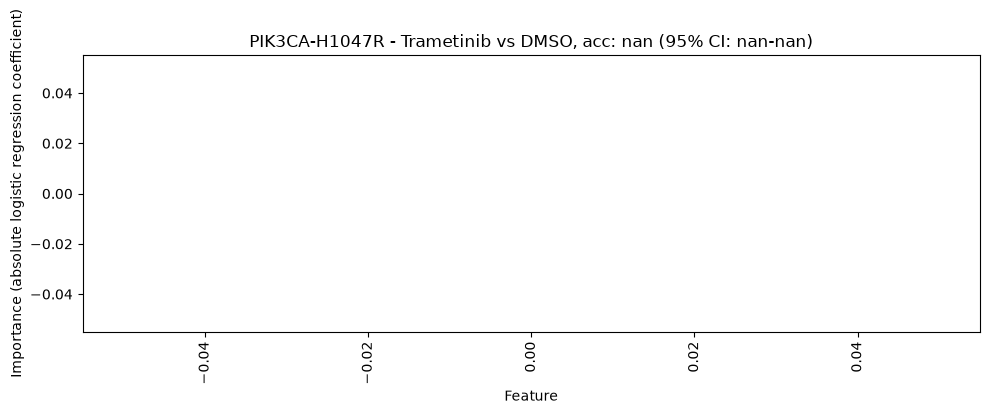

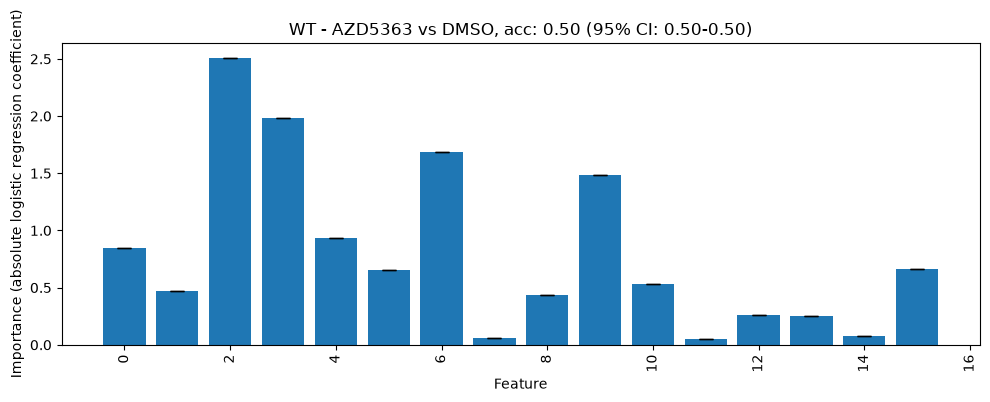

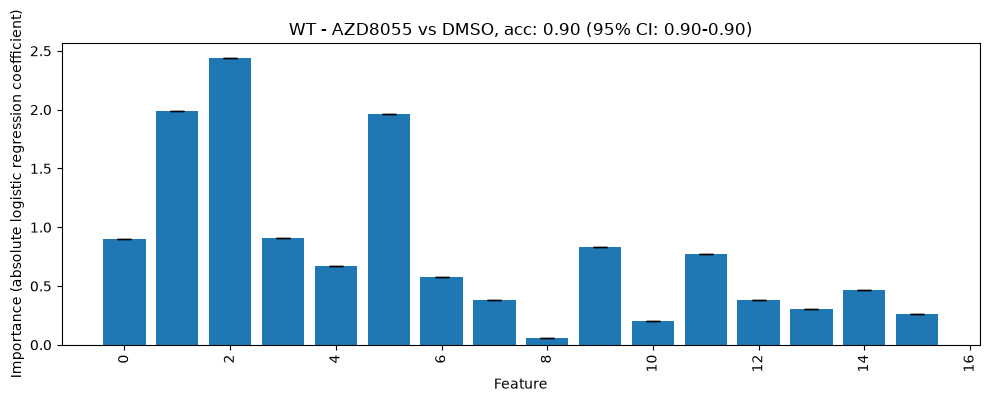

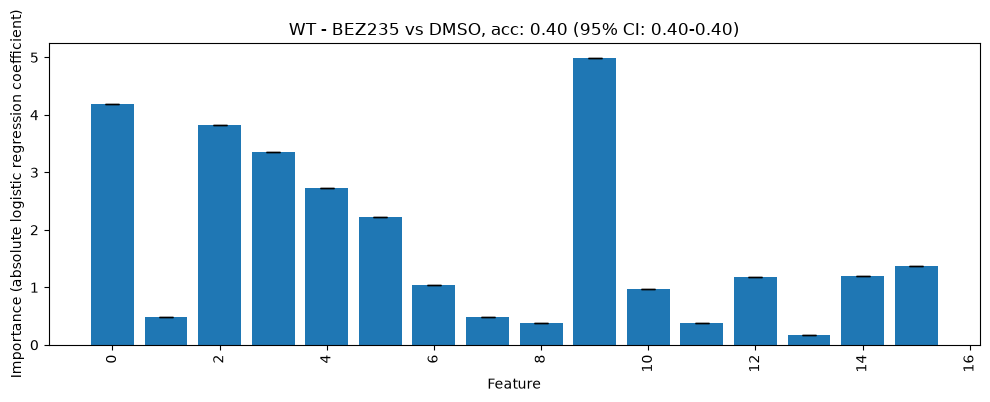

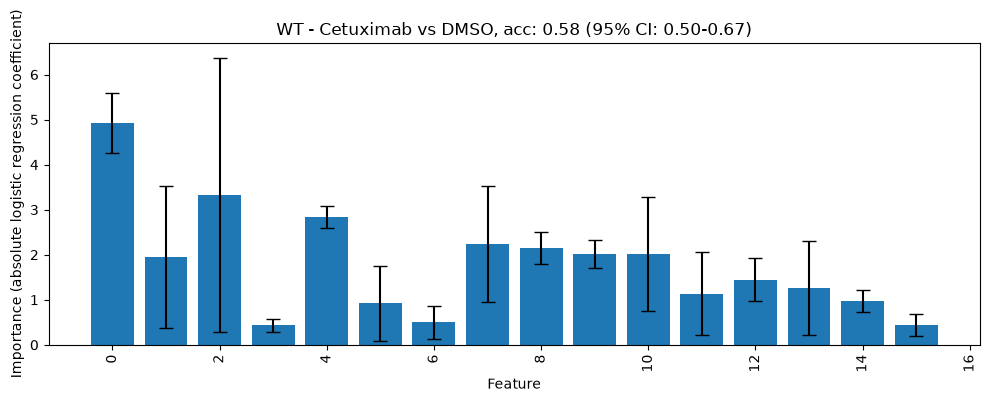

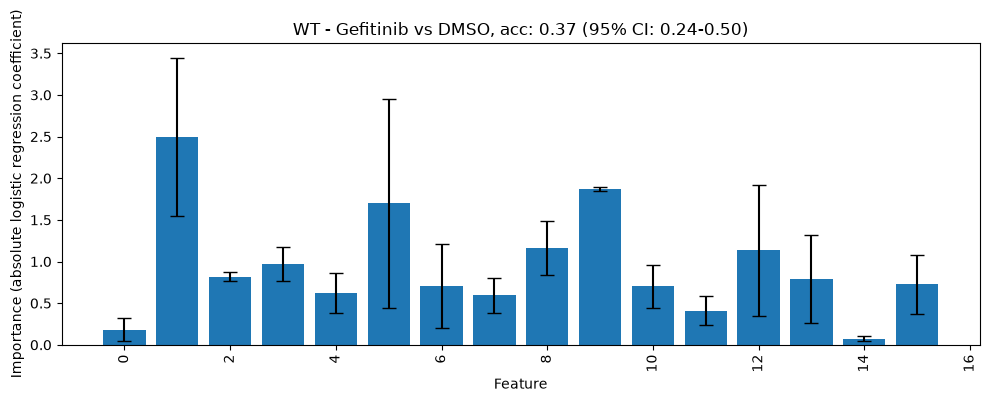

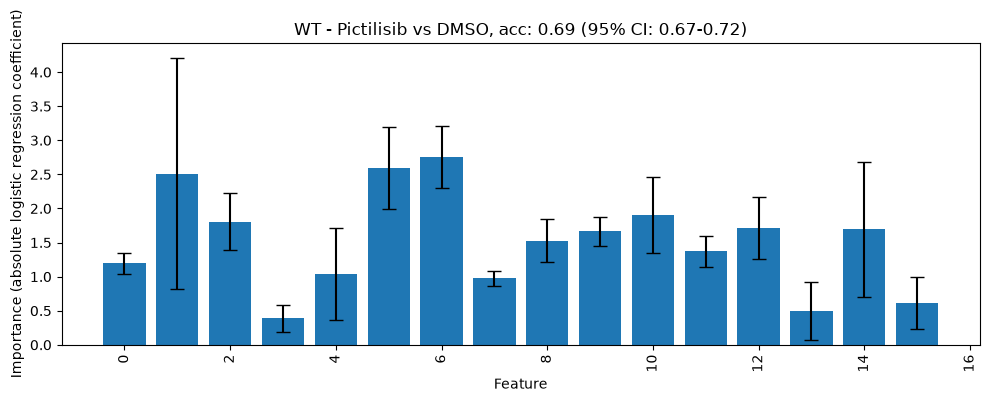

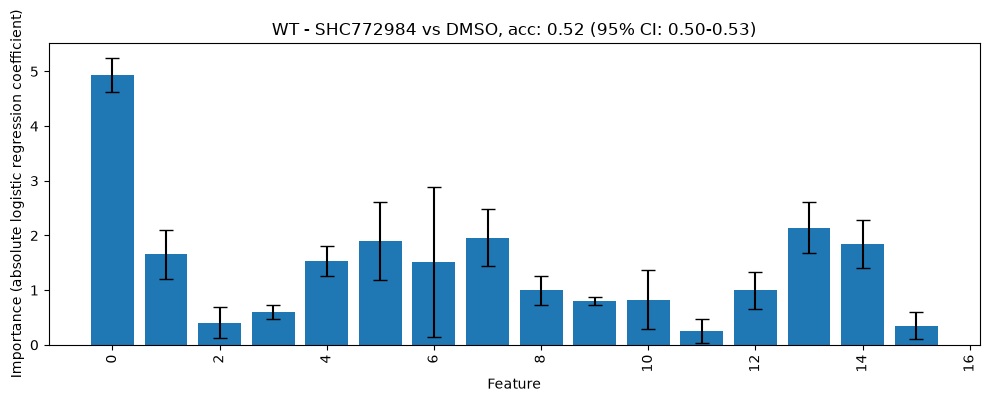

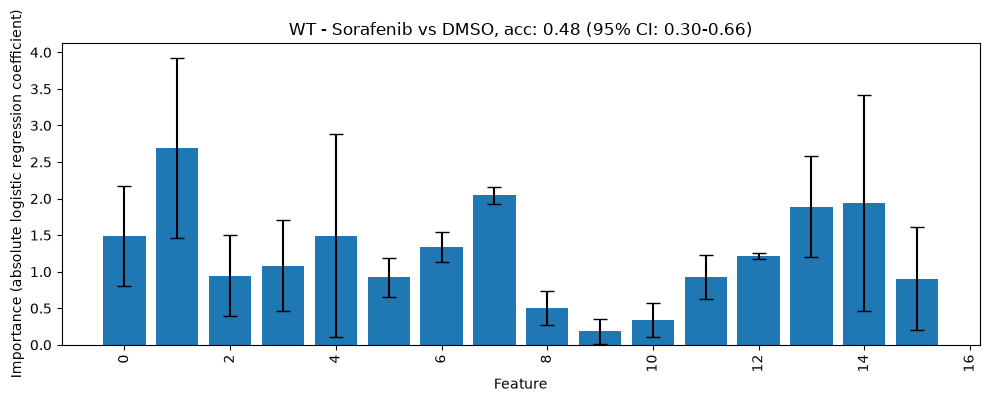

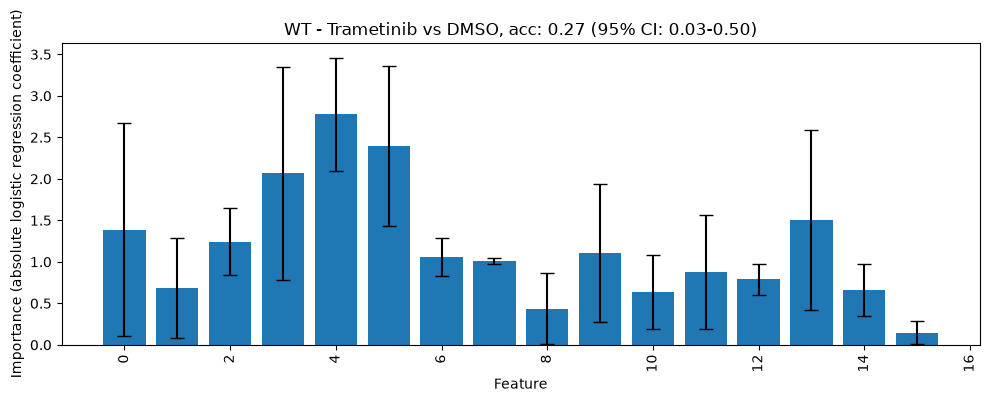

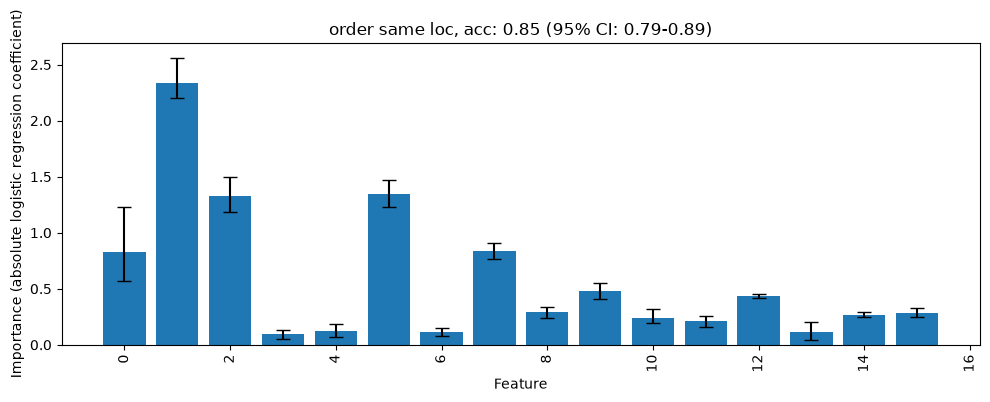

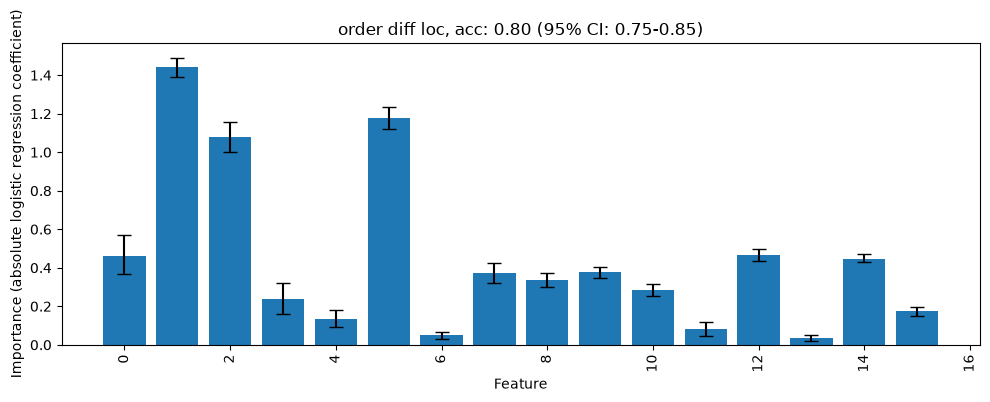

In [ ]:
import matplotlib.pyplot as plt

for index in range(len(res)):
    importances = res[index]["imps"]
    features = range(len(importances))
    importances_lo = res[index]["imps_lo"]
    importances_hi = res[index]["imps_hi"]

    plt.figure(figsize=(10, 4))
    plt.bar(features, importances)
    plt.errorbar(features, importances, yerr=[np.array(importances) - np.array(importances_lo), np.array(importances_hi) - np.array(importances)], fmt='none', ecolor='black', capsize=5)
    plt.xlabel("Feature")
    plt.ylabel("Importance (absolute logistic regression coefficient)")
    plt.title(res[index]["label_name"] + ", acc: {:.2f} (95% CI: {:.2f}-{:.2f})".format(res[index]["acc"], res[index]["acc_lo"], res[index]["acc_hi"]))
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()